### Imports

In [2]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pyopencl as cl

### 8a RGB-Bild einlesen und in ein Graustufenbild umwandeln

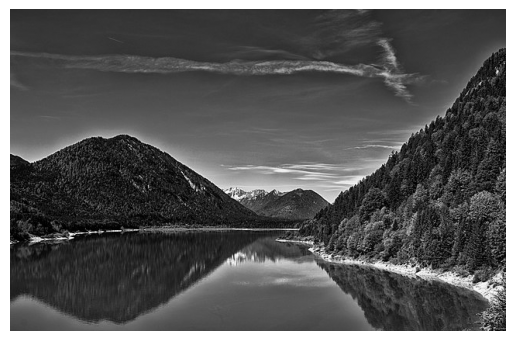

In [ ]:
image_path = Path("images_input/1.nature_small.jpeg")

image = Image.open(image_path)
rgb_matrix = np.array(image, dtype=np.uint8)

height, width, channels = rgb_matrix.shape
pixel_count = height * width

rgb_flat = rgb_matrix.flatten()
gray_flat = np.empty(pixel_count, dtype=np.uint8)

context = cl.create_some_context()
queue = cl.CommandQueue(context)

mf = cl.mem_flags
rgb_buffer = cl.Buffer(context,  mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=rgb_flat)
gray_buffer = cl.Buffer(context, mf.WRITE_ONLY, gray_flat.nbytes)

program = cl.Program(context, """
__kernel void rgb_to_grayscale(
    __global const uchar *rgb,
    __global uchar *gray
)
{
    int pixel_id = get_global_id(0);
    int rgb_id = pixel_id * 3;

    uchar red = rgb[rgb_id];
    uchar green = rgb[rgb_id + 1];
    uchar blue = rgb[rgb_id + 2];

    gray[pixel_id] = (uchar)(0.21f * red + 0.72f * green + 0.07f * blue);
}
""").build()

program.rgb_to_grayscale(
    queue,
    (pixel_count,),
    None,
    rgb_buffer,
    gray_buffer
)

cl.enqueue_copy(queue, gray_flat, gray_buffer)

gray_matrix = gray_flat.reshape((height, width))

plt.imshow(gray_matrix, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()